In [5]:
from dotenv import load_dotenv
load_dotenv()

import os
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")


In [ ]:
from langchain_core.messages import AIMessage,HumanMessage
from pprint import pprint

messages = [AIMessage(content=f"Please Tell Me How Can I Help You",name="LLMModel")]
messages.append(HumanMessage(content=f"I Want To Learn Coding",name="Rajat"))
messages.append(AIMessage(content=f"Which Programming Language U want to Learn",name="LLMModel"))

for message in messages:
    message.pretty_print()

================================== Ai Message ==================================
Name: LLMModel

Please Tell Me How Can I Help You
================================ Human Message =================================
Name: Krish

I Want To Learn Coding
================================== Ai Message ==================================
Name: LLMModel

Which Programming Language U want to Learn


In [ ]:
from langchain_groq import ChatGroq
model = ChatGroq(
    model="openai/gpt-oss-120b",
)

model

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.1', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001B39299C590>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001B39299D2B0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [8]:
model.invoke(messages)

AIMessage(content='Great! Choosing a language that matches your goals makes the learning process smoother. Here are a few common paths and the languages that fit them:\n\n| Goal | Recommended Language(s) | Why It’s a Good Fit |\n|------|--------------------------|---------------------|\n| **Web development (front‑end)** | **HTML, CSS, JavaScript** | These are the core building blocks of any website. JavaScript also lets you add interactivity. |\n| **Web development (back‑end)** | **JavaScript (Node.js), Python, Ruby, PHP, Java, C#** | All have strong frameworks (Express, Django/Flask, Rails, Laravel, Spring, ASP.NET) for building servers and APIs. |\n| **Mobile apps** | **Swift (iOS), Kotlin (Android), Java (Android), React Native (JavaScript), Flutter (Dart)** | Native languages give the best performance; cross‑platform frameworks let you write once for both platforms. |\n| **Data science / Machine learning** | **Python, R** | Python’s libraries (pandas, NumPy, scikit‑learn, TensorFlo

In [9]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


class State(TypedDict):
    name: str


def uppercase(state):
    return {
        "name": state["name"].upper()
    }


def greeting(state):
    return {
        "name": "Hello " + state["name"]
    }


graph = StateGraph(State)

graph.add_node("uppercase", uppercase)
graph.add_node("greeting", greeting)

graph.add_edge(START, "uppercase")
graph.add_edge("uppercase", "greeting")
graph.add_edge("greeting", END)

app = graph.compile()

result = app.invoke({
    "name": "rajat"
})

print(result)

{'name': 'Hello RAJAT'}


## TOOLS

In [77]:
def add(a:int,b:int)->int:
    """ Add a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int
    """
    return a+b
    

In [78]:
model
model_with_tools = model.bind_tools([add])

In [79]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class State(TypedDict):
    message:list[AnyMessage]

In [80]:
from langgraph.graph.message import add_messages
from typing import Annotated

class State(TypedDict):
    message:Annotated[list[AnyMessage],add_messages]


In [81]:
initial_messages = [AIMessage(content=f"Please Tell Me How Can I Help You",name="LLMModel")]
initial_messages.append(HumanMessage(content=f"I Want To Learn Coding",name="Rajat"))
initial_messages

[AIMessage(content='Please Tell Me How Can I Help You', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I Want To Learn Coding', additional_kwargs={}, response_metadata={}, name='Rajat')]

In [82]:
ai_message = (AIMessage(content=f"Which Programming Language U want to Learn",name="LLMModel"))

In [83]:
def llm_tool(state:State):
    return{"messages":[model_with_tools.invoke(state["message"])]}

In [84]:
from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END
builder = StateGraph(State)
builder.add_node("llm_tool",llm_tool)
builder.add_edge(START,"llm_tool")
builder.add_edge("llm_tool",END)

app = builder.compile()



In [85]:
message = app.invoke({"message":"what is 2 plus 2"})

In [86]:
message

{'message': [HumanMessage(content='what is 2 plus 2', additional_kwargs={}, response_metadata={}, id='9ccc7258-fd33-4b47-b1d4-c016275c7396')]}

In [87]:
tools=[add]

In [88]:
from langgraph.prebuilt import ToolNode,tools_condition
builder  = StateGraph(State)

In [89]:
builder.add_node("llm_tool",llm_tool)
builder.add_node("tools",ToolNode(tools))
builder.add_edge(START,"llm_tool")
builder.add_conditional_edges(
    "llm_tool",
    tools_condition
)
builder.add_edge("tools",END)
builder_graph= builder.compile()

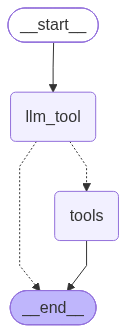

In [90]:
display(Image(builder_graph.get_graph().draw_mermaid_png()))

In [94]:
from langchain_core.messages import HumanMessage

message = builder_graph.invoke({
    "message": [
        HumanMessage(content="What is 2 plus 2")
    ]
})

for messages in message["message"]:
    messages.pretty_print()

================================ Human Message =================================

What is 2 plus 2
